In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys
sys.path.append(os.path.abspath('..'))
from src.data import save_data, get_raw

In [32]:
df = get_raw()
df.head()

Đã đọc thành công dữ liệu thô từ: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\raw\electricity_data.parquet


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# Resample theo giờ và tính tổng toàn bộ khách hàng
df = (
    df
    .resample("H")
    .sum()
    .sum(axis=1)
    .div(4)
)

# Chuyển thành DataFrame
df = df.to_frame(name="total_load")
df.head()

,total_load
Timestamp,
2011-01-01 00:00:00,51764.567568
2011-01-01 01:00:00,66344.627687
2011-01-01 02:00:00,65981.054883
2011-01-01 03:00:00,66576.533566
2011-01-01 04:00:00,64963.552675


In [34]:
df.tail()

,total_load
Timestamp,
2014-12-31 20:00:00,166951.192473
2014-12-31 21:00:00,156247.443652
2014-12-31 22:00:00,145213.196110
2014-12-31 23:00:00,128488.047547
2015-01-01 00:00:00,31053.549804


In [35]:
# Kiểm tra số lượng giá trị 0
(df["total_load"] == 0).sum()

0

In [36]:
# Xóa ngày đầu tiên của 2015
df = df[df.index < "2015-01-01"]

# Chỉ lấy dữ liệu từ năm 2012 trở đi
# df = df.loc["2012":]

display(df.head())
display(df.tail())

,total_load
Timestamp,
2011-01-01 00:00:00,51764.567568
2011-01-01 01:00:00,66344.627687
2011-01-01 02:00:00,65981.054883
2011-01-01 03:00:00,66576.533566
2011-01-01 04:00:00,64963.552675


,total_load
Timestamp,
2014-12-31 19:00:00,202877.313799
2014-12-31 20:00:00,166951.192473
2014-12-31 21:00:00,156247.443652
2014-12-31 22:00:00,145213.196110
2014-12-31 23:00:00,128488.047547


In [37]:
# =====================================================
# 2. DST MARCH (23-HOUR DAY)
# Thay thế bằng NaN và dùng Nội suy tuyến tính (Linear Interpolation)
# Tránh tuyệt đối Data Leakage từ next_week
# =====================================================
march_dst = [
    "2012-03-25 01:00:00",
    "2013-03-31 01:00:00",
    "2014-03-30 01:00:00"
]

# Đổi giá trị 0kW tại các giờ này thành NaN
for t in march_dst:
    t = pd.Timestamp(t)
    if t in df.index:
        df.loc[t] = np.nan

# Lệnh nội suy này sẽ tự động lấy (0h00 + 2h00) / 2 của chính ngày hôm đó
df = df.interpolate(method='linear')

# =====================================================
# 3. DST OCTOBER (25-HOUR DAY)
# Giờ bị nhân đôi -> Chia 2
# =====================================================
october_dst = [
    "2012-10-28 01:00:00",
    "2013-10-27 01:00:00",
    "2014-10-26 01:00:00"
]

for t in october_dst:
    t = pd.Timestamp(t)
    if t in df.index:
        df.loc[t] = df.loc[t] / 2

# =====================================================
# 4. TOTAL LOAD
# =====================================================
df["total_load"] = df.sum(axis=1)

display(df.head())

,total_load
Timestamp,
2011-01-01 00:00:00,51764.567568
2011-01-01 01:00:00,66344.627687
2011-01-01 02:00:00,65981.054883
2011-01-01 03:00:00,66576.533566
2011-01-01 04:00:00,64963.552675


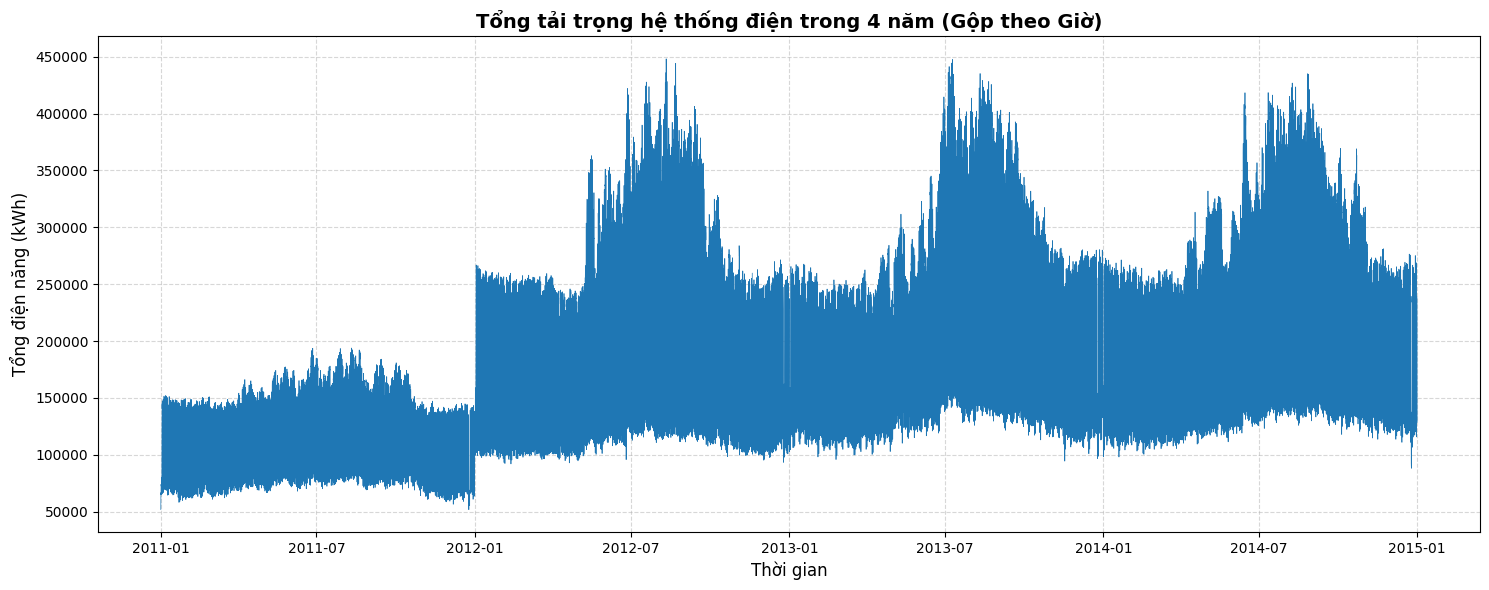

In [38]:
import matplotlib.pyplot as plt

# Thiết lập kích thước biểu đồ lớn để nhìn rõ 4 năm
plt.figure(figsize=(15, 6))

# Vẽ đường biểu diễn tổng tải trọng
plt.plot(df.index, df['total_load'], color='#1f77b4', linewidth=0.5)

plt.title('Tổng tải trọng hệ thống điện trong 4 năm (Gộp theo Giờ)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tổng điện năng (kWh)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

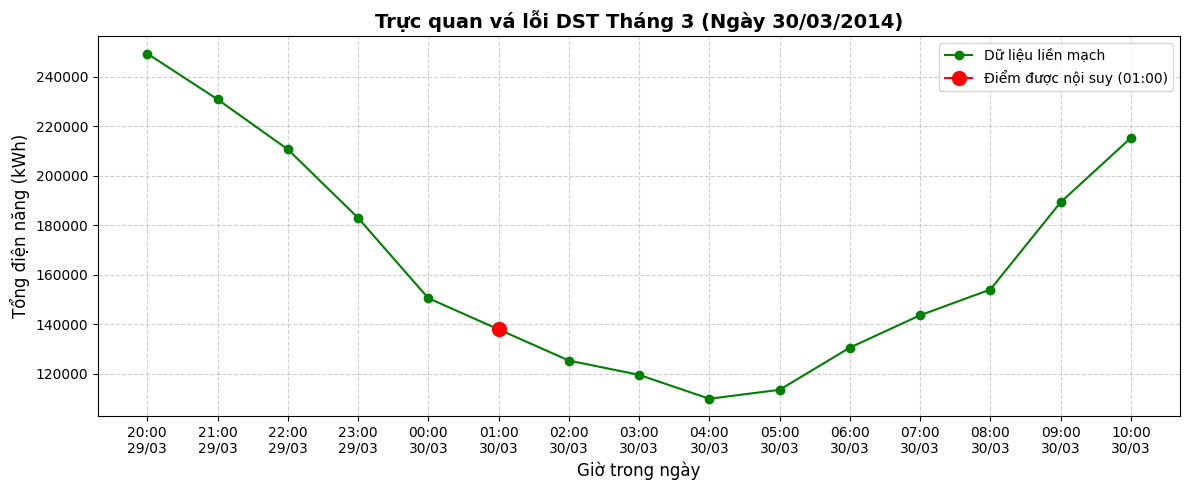

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Chọn cửa sổ thời gian 14 tiếng xung quanh điểm nội suy tháng 3
start_mar = '2014-03-29 20:00:00'
end_mar = '2014-03-30 10:00:00'
df_mar = df.loc[start_mar:end_mar]

# Xác định chính xác điểm đã nội suy
interp_point = pd.Timestamp('2014-03-30 01:00:00')

plt.figure(figsize=(12, 5))

# Vẽ đường dữ liệu với các điểm đánh dấu (marker)
plt.plot(df_mar.index, df_mar['total_load'], marker='o', linestyle='-', color='green', label='Dữ liệu liền mạch')

# Nhấn mạnh điểm 01:00 sáng bằng một chấm lớn màu đỏ
plt.plot(interp_point, df.loc[interp_point, 'total_load'], marker='o', markersize=10, color='red', label='Điểm được nội suy (01:00)')

plt.title('Trực quan vá lỗi DST Tháng 3 (Ngày 30/03/2014)', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày', fontsize=12)
plt.ylabel('Tổng điện năng (kWh)', fontsize=12)

# Ép trục X hiển thị định dạng Giờ:Phút và Ngày
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d/%m'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # Hiển thị mốc từng giờ một

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

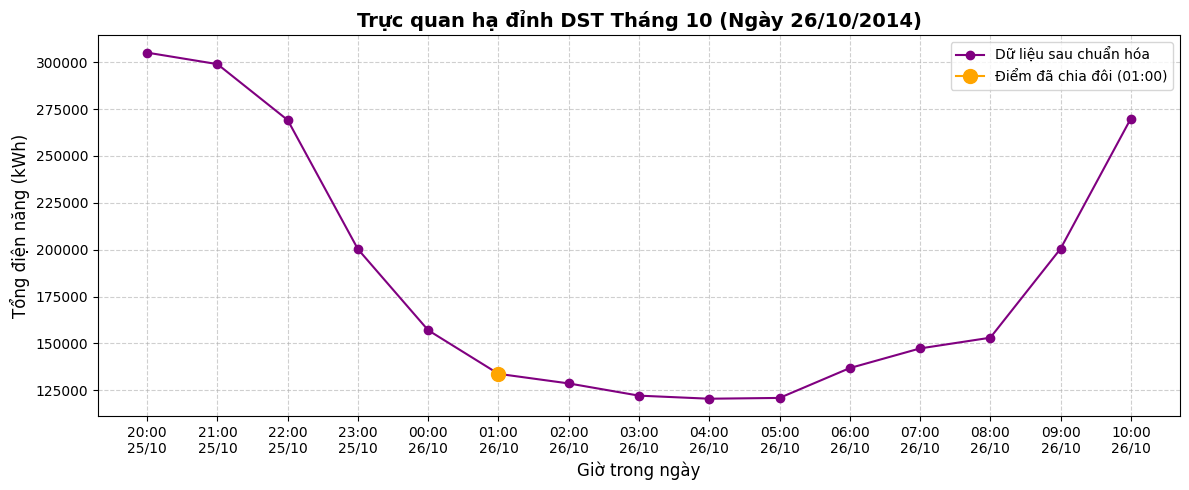

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Chọn cửa sổ thời gian 14 tiếng xung quanh điểm chia đôi tháng 10
start_oct = '2014-10-25 20:00:00'
end_oct = '2014-10-26 10:00:00'
df_oct = df.loc[start_oct:end_oct]

# Xác định chính xác điểm đã chia 2
div_point = pd.Timestamp('2014-10-26 01:00:00')

plt.figure(figsize=(12, 5))

# Vẽ đường dữ liệu
plt.plot(df_oct.index, df_oct['total_load'], marker='o', linestyle='-', color='purple', label='Dữ liệu sau chuẩn hóa')

# Nhấn mạnh điểm 01:00 sáng bằng một chấm lớn màu cam
plt.plot(div_point, df.loc[div_point, 'total_load'], marker='o', markersize=10, color='orange', label='Điểm đã chia đôi (01:00)')

plt.title('Trực quan hạ đỉnh DST Tháng 10 (Ngày 26/10/2014)', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày', fontsize=12)
plt.ylabel('Tổng điện năng (kWh)', fontsize=12)

# Ép trục X hiển thị định dạng Giờ:Phút và Ngày
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d/%m'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1)) # Hiển thị mốc từng giờ một

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [41]:
df.shape

(35064, 1)

In [42]:
def create_static_features(df):
    df = df.copy()
    
    # 2. Đặc trưng lịch (Calendar Features)
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['day_of_month'] = df.index.day
    df['day_of_year'] = df.index.dayofyear
    df['week_of_year'] = df.index.isocalendar().week.astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # 3. Đặc trưng vòng lặp (Cyclical Features - Sin/Cos)
    # Vòng lặp Ngày (24h)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Vòng lặp Tuần (7 ngày)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # Vòng lặp Tháng (12 tháng)
    df['month_sin'] = np.sin(2 * np.pi * (df['month']-1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month']-1) / 12)
    
    # Vòng lặp Năm (365.25 ngày) - Cực kỳ quan trọng để thay thế Lag năm
    df['year_sin'] = np.sin(2 * np.pi * (df['day_of_year']-1) / 365.25)
    df['year_cos'] = np.cos(2 * np.pi * (df['day_of_year']-1) / 365.25)

    return df

# Thực thi
df_features = create_static_features(df)

# Kiểm tra dữ liệu
print("Các cột đặc trưng tĩnh:")
print(df_features.columns.tolist())

Các cột đặc trưng tĩnh:
['total_load', 'hour', 'day_of_week', 'quarter', 'month', 'day_of_month', 'day_of_year', 'week_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos']


In [43]:
df_features.head()

,total_load,hour,day_of_week,quarter,month,day_of_month,day_of_year,week_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,year_sin,year_cos
Timestamp,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,51764.567568,0,5,1,1,1,1,52,1,0.000000,1.000000,-0.974928,-0.222521,0.0,1.0,0.0,1.0
2011-01-01 01:00:00,66344.627687,1,5,1,1,1,1,52,1,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0,0.0,1.0
2011-01-01 02:00:00,65981.054883,2,5,1,1,1,1,52,1,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0,0.0,1.0
2011-01-01 03:00:00,66576.533566,3,5,1,1,1,1,52,1,0.707107,0.707107,-0.974928,-0.222521,0.0,1.0,0.0,1.0
2011-01-01 04:00:00,64963.552675,4,5,1,1,1,1,52,1,0.866025,0.500000,-0.974928,-0.222521,0.0,1.0,0.0,1.0


In [44]:
import holidays

def create_holidays_features(df):
    df = df.copy()
    
    # 1. Khởi tạo lịch
    pt_holidays = holidays.Portugal(years=range(2011, 2014))  # Lấy lịch từ 2011 đến 2014 (có thể mở rộng nếu cần)

    # 2. Tạo cột tên ngày lễ (Lấy tên gốc từ thư viện)
    # Nếu không phải ngày lễ, để là "None"
    df['holiday_name'] = df.index.normalize().map(lambda d: pt_holidays.get(d) if d in pt_holidays else "None")

    # 3. Chuyển đổi tên ngày lễ thành số (Label Encoding) để LightGBM dễ học
    # Các ngày lễ giống nhau qua các năm sẽ có cùng một mã số
    df['holiday_name'] = df['holiday_name'].astype('category')

    return df

df_final = create_holidays_features(df_features)
df_final.head()

,total_load,hour,day_of_week,quarter,month,day_of_month,day_of_year,week_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,year_sin,year_cos,holiday_name
Timestamp,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,51764.567568,0,5,1,1,1,1,52,1,0.000000,1.000000,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 01:00:00,66344.627687,1,5,1,1,1,1,52,1,0.258819,0.965926,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 02:00:00,65981.054883,2,5,1,1,1,1,52,1,0.500000,0.866025,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 03:00:00,66576.533566,3,5,1,1,1,1,52,1,0.707107,0.707107,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo
2011-01-01 04:00:00,64963.552675,4,5,1,1,1,1,52,1,0.866025,0.500000,-0.974928,-0.222521,0.0,1.0,0.0,1.0,Ano Novo


In [45]:
import sys,os
sys.path.append(os.path.abspath('..'))
from src.data import save_data

save_data(df_final, "df_clean")

Đã lưu thành công tại: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\processed\df_clean
